# Pharmacy2U — Data Access Test

**Welcome Fidan and Nilavan.**

This notebook checks that you can connect to the Azure ML workspace and read each of the main data tables you'll be working with.

Run each cell in order. If a cell fails, the error message will tell us what to fix — Teams me a screenshot and we'll sort it.

**Today's goal: every cell completes without error.** That's it. Real analysis starts tomorrow.

A note on the data: this is a snapshot of P2U's prescription, order and dispensing data. Patient identifiers are opaque (no names, no addresses). Treat all of it as confidential — don't copy anything out of the workspace.

---

## 0. Kernel and dependencies

**Use the `Python 3.10 - AzureML` kernel** (top-right of the notebook). That kernel comes with `azure-ai-ml` and the other Azure libraries preinstalled.

If you're on a different kernel, or the imports in section 1 fail with `ModuleNotFoundError: No module named 'azure.ai.ml'`, run the install cell below first. It's safe to run either way — pip will skip what's already installed.

After running the install, if imports still fail, restart the kernel (Kernel menu → Restart) and try again.

In [1]:
# Defensive install — safe to run even if libraries are already present.
# Quiet (-q) so we don't get pages of output.
%pip install -q azure-ai-ml azure-identity azure-storage-blob pyarrow pandas matplotlib

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
adlfs 2025.8.0 requires fsspec>=2023.12.0, but you have fsspec 2023.10.0 which is incompatible.
azure-cli 2.81.0 requires azure-datalake-store~=1.0.1, but you have azure-datalake-store 0.0.53 which is incompatible.
azure-cli 2.81.0 requires azure-keyvault-keys==4.11.0, but you have azure-keyvault-keys 4.8.0 which is incompatible.
azure-cli 2.81.0 requires azure-mgmt-keyvault==12.1.0, but you have azure-mgmt-keyvault 10.3.1 which is incompatible.
azure-cli 2.81.0 requires azure-mgmt-storage==24.0.0, but you have azure-mgmt-storage 22.0.0 which is incompatible.
azure-cli 2.81.0 requires websocket-client~=1.3.1, but you have websocket-client 1.9.0 which is incompatible.
azure-cli-core 2.81.0 requires azure-core~=1.35.0, but you have azure-core 1.41.0 which is incompatible.
azureml-automl-dnn-nlp 1.61.0 requires torch

---

## 1. Imports

Standard data-science stack plus the three Azure libraries we need.

In [2]:
import io
import re
import sys
from collections import Counter

import pandas as pd
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

from azure.identity import DefaultAzureCredential
from azure.ai.ml import MLClient
from azure.storage.blob import BlobServiceClient

# A bit of display polish
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 180)
plt.rcParams.update({"figure.dpi": 100, "font.size": 10, "figure.facecolor": "white"})

print(f"Python  : {sys.version.split()[0]}")
print(f"pandas  : {pd.__version__}")
print(f"pyarrow : {pa.__version__}")
print("Imports OK")

Python  : 3.10.11
pandas  : 1.5.3
pyarrow : 14.0.2
Imports OK


---

## 2. Connect to the Azure ML workspace and blob storage

Authenticates against P2U's Smart Reminders ML workspace and gets a handle on the blob storage container.

**What to expect the first time you run this:** the cell will print a line like

> *To sign in, use a web browser to open the page https://microsoft.com/devicelogin and enter the code ABCDEFGHI to authenticate.*

Open that link in any browser (your laptop is fine), enter the code, sign in with your `@pharmacy2u.co.uk` account. The cell completes once you've done it.

On subsequent runs in the same session it's silent — the token is cached.

In [3]:
# P2U Smart Reminders workspace
SUBSCRIPTION_ID = "e3f80064-70e1-47b8-a1ea-fe9938349b16"
RESOURCE_GROUP  = "SMRT-TEMP-RG"
WORKSPACE_NAME  = "SMRT-TEMP-AML00"

from azure.identity import AzureCliCredential, DeviceCodeCredential

# Scope we request a token against — used to verify a credential actually works
SCOPE = "https://management.azure.com/.default"


def get_credential():
    """Try credentials in order of reliability for Azure ML compute notebooks.

    Azure ML compute's managed identity endpoint is broken on fresh instances
    (returns text/plain instead of JSON), so we skip it and fall through to
    Azure CLI then device-code sign-in. Device code is the right fallback for
    Azure ML compute because there is no display server to open a browser.
    """

    # 1) DefaultAzureCredential WITHOUT managed identity.
    #    Skips the broken MI endpoint. Will succeed if anything else in the
    #    default chain works (e.g. prior az login).
    try:
        cred = DefaultAzureCredential(exclude_managed_identity_credential=True)
        cred.get_token(SCOPE)
        print("[auth] DefaultAzureCredential (managed identity excluded) — OK")
        return cred
    except Exception as e:
        print(f"[auth] DefaultAzureCredential: {type(e).__name__}")

    # 2) Explicit Azure CLI credential.
    #    Works silently if you have previously run `az login --use-device-code`
    #    in a terminal on this compute instance.
    try:
        cred = AzureCliCredential()
        cred.get_token(SCOPE)
        print("[auth] AzureCliCredential (from prior az login) — OK")
        return cred
    except Exception as e:
        print(f"[auth] AzureCliCredential: {type(e).__name__}")

    # 3) Device-code flow.
    #    Prints a URL + code into the cell output. Open the URL in any browser,
    #    paste the code, sign in. Works on headless compute (no browser needed
    #    on the compute instance itself).
    print("[auth] Falling back to device-code sign-in — see prompt below.")
    cred = DeviceCodeCredential()
    cred.get_token(SCOPE)
    print("[auth] DeviceCodeCredential — OK")
    return cred


# --- Authenticate ---
credential = get_credential()

# --- Workspace ---
ml_client = MLClient(credential, SUBSCRIPTION_ID, RESOURCE_GROUP, WORKSPACE_NAME)
print(f"Workspace : {ml_client.workspace_name}")

# --- Datastore ---
datastore = ml_client.datastores.get("workspaceblobstore")
print(f"Datastore : {datastore.name}")
print(f"  account   : {datastore.account_name}")
print(f"  container : {datastore.container_name}")

# --- Blob container handle (reuses the same credential) ---
blob_service = BlobServiceClient(
    account_url=f"https://{datastore.account_name}.blob.core.windows.net",
    credential=credential,
)
container = blob_service.get_container_client(datastore.container_name)
print(f"Container : {container.container_name}")

DefaultAzureCredential failed to retrieve a token from the included credentials.
Attempted credentials:
	EnvironmentCredential: EnvironmentCredential authentication unavailable. Environment variables are not fully configured.
Visit https://aka.ms/azsdk/python/identity/environmentcredential/troubleshoot to troubleshoot this issue.
	SharedTokenCacheCredential: SharedTokenCacheCredential authentication unavailable. No accounts were found in the cache.
	AzureCliCredential: Please run 'az login' to set up an account
	AzurePowerShellCredential: PowerShell is not installed
	AzureDeveloperCliCredential: Azure Developer CLI could not be found. Please visit https://aka.ms/azure-dev for installation instructions and then,once installed, authenticate to your Azure account using 'azd auth login'.
To mitigate this issue, please refer to the troubleshooting guidelines here at https://aka.ms/azsdk/python/identity/defaultazurecredential/troubleshoot.


[auth] DefaultAzureCredential: ClientAuthenticationError
[auth] AzureCliCredential: CredentialUnavailableError
[auth] Falling back to device-code sign-in — see prompt below.
To sign in, use a web browser to open the page https://login.microsoft.com/device and enter the code DAX8Y2TEN to authenticate.
[auth] DeviceCodeCredential — OK
Workspace : SMRT-TEMP-AML00
Datastore : workspaceblobstore
  account   : smrttempsa
  container : azureml-blobstore-9c0e725a-1db2-4e2b-83ed-97bbde32f29b
Container : azureml-blobstore-9c0e725a-1db2-4e2b-83ed-97bbde32f29b


---

## 3. Helper functions + snapshot auto-detect

Three small helpers we'll reuse for every table, plus a one-time discovery of the latest snapshot folder so we're never reading stale data.

In [4]:
ROOT_PREFIX = "landing/p2u_smartreminders"

def find_latest_snapshot() -> str:
    """Find the most recent YYYYMMDD snapshot folder under the root prefix."""
    snapshots = set()
    for blob in container.list_blobs(name_starts_with=f"{ROOT_PREFIX}/"):
        parts = blob.name.split("/")
        if len(parts) >= 3 and re.fullmatch(r"\d{8}", parts[2]):
            snapshots.add(parts[2])
    if not snapshots:
        raise RuntimeError(f"No YYYYMMDD snapshot folders found under {ROOT_PREFIX}/")
    return sorted(snapshots)[-1]

LATEST_SNAPSHOT = find_latest_snapshot()
BASE_PATH = f"{ROOT_PREFIX}/{LATEST_SNAPSHOT}"
print(f"Latest snapshot: {LATEST_SNAPSHOT}")
print(f"BASE_PATH      : {BASE_PATH}")

def list_table_files(table_name: str) -> list:
    """All parquet files for a given table in the latest snapshot."""
    prefix = f"{BASE_PATH}/{table_name}/"
    return sorted([
        b.name for b in container.list_blobs(name_starts_with=prefix)
        if b.name.endswith(".parquet")
    ])

def read_first_parquet(blob_path: str, n_rows: int = 5) -> pd.DataFrame:
    """Read the first row-group from a parquet file. Returns first N rows."""
    data = container.download_blob(blob_path).readall()
    pf = pq.ParquetFile(io.BytesIO(data))
    if pf.num_row_groups == 0:
        # Empty parquet — return an empty DF with the right columns
        return pd.DataFrame(columns=pf.schema.names)
    return pf.read_row_group(0).to_pandas().head(n_rows)

# We collect test results here so we can summarise at the end
test_results: list = []

def test_table(table_name: str) -> pd.DataFrame:
    """Test access to one table. Logs result and returns a 5-row preview."""
    print(f"\n--- {table_name} " + "-" * (60 - len(table_name)))
    files = list_table_files(table_name)
    if not files:
        print(f"  WARNING: no parquet files at {BASE_PATH}/{table_name}/")
        test_results.append({"table": table_name, "files": 0, "columns": 0, "status": "MISSING"})
        return None
    try:
        sample = read_first_parquet(files[0], n_rows=5)
        print(f"  Files    : {len(files)}")
        print(f"  Sample   : {files[0].split('/')[-1]}")
        print(f"  Columns ({len(sample.columns)}): {list(sample.columns)}")
        test_results.append({
            "table": table_name,
            "files": len(files),
            "columns": len(sample.columns),
            "status": "OK",
        })
        return sample
    except Exception as e:
        print(f"  ERROR: {type(e).__name__}: {e}")
        test_results.append({"table": table_name, "files": len(files), "columns": 0, "status": "ERROR"})
        return None

print("\nHelpers loaded")

Latest snapshot: 20251016
BASE_PATH      : landing/p2u_smartreminders/20251016

Helpers loaded


---

## 4. Discover what tables exist in the snapshot

Quick inventory of everything that's there. The bar chart at the end gives you a visual sense of which tables are large vs small.

Snapshot           : 20251016
Total parquet files: 1,465
Tables found       : 13

             table  parquet_files
             Order            358
  PrescriptionItem            332
 RepeatItemHistory            247
      Prescription            185
          Despatch            140
     RequestHeader             95
        RepeatItem             45
            Repeat             39
          enriched             16
   test_evaluation              5
tbl_dispensed_dose              1
        tbl_dosage              1
  tbl_dose_mapping              1


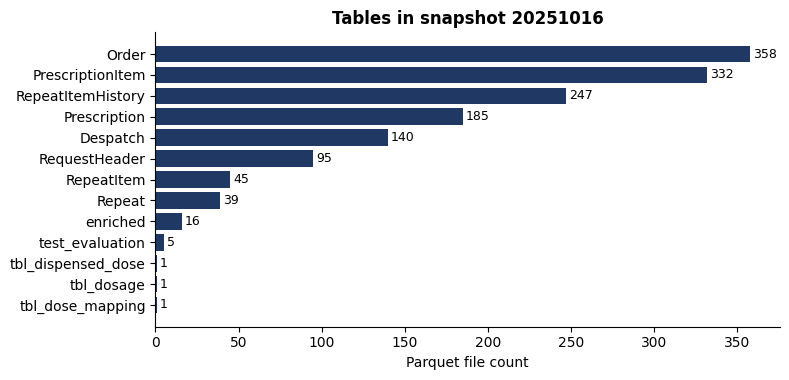

In [5]:
all_blobs = list(container.list_blobs(name_starts_with=f"{BASE_PATH}/"))
parquet_files = [b.name for b in all_blobs if b.name.endswith(".parquet")]

table_counter: Counter = Counter()
for path in parquet_files:
    parts = path.split("/")
    if len(parts) >= 4:
        table_counter[parts[3]] += 1

print(f"Snapshot           : {LATEST_SNAPSHOT}")
print(f"Total parquet files: {len(parquet_files):,}")
print(f"Tables found       : {len(table_counter)}")
print()
inventory = pd.DataFrame(
    sorted(table_counter.items(), key=lambda kv: -kv[1]),
    columns=["table", "parquet_files"],
)
print(inventory.to_string(index=False))

# Bar chart — relative table sizes by file count
fig, ax = plt.subplots(figsize=(8, max(3, 0.3 * len(inventory))))
ax.barh(inventory["table"][::-1], inventory["parquet_files"][::-1], color="#1F3864")
ax.set_xlabel("Parquet file count")
ax.set_title(f"Tables in snapshot {LATEST_SNAPSHOT}", fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
for i, v in enumerate(inventory["parquet_files"][::-1]):
    ax.text(v + max(inventory["parquet_files"]) * 0.005, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.show()

---

## 5. Load a sample from each main table

Each cell below loads the first parquet file from one table and shows columns + a 5-row preview. **This is the actual test.** If every cell prints without error and shows a small DataFrame, your access is working.

Tables are grouped by the area you'll use them in. If a table prints `MISSING`, it isn't in the snapshot under that name — the discovery cell above shows what is.

### 5a. Prescription and dispatch data

In [6]:
test_table("Prescription")


--- Prescription ------------------------------------------------
  Files    : 185
  Sample   : part-00000.parquet
  Columns (28): ['PrescriptionID', 'PrescriptionGUID', 'ShortPrescriptionUUID', 'PatientID', 'OrderID', 'PrescriptionTypeName', 'IssueDate', 'DateReceived', 'StatusText', 'PrescribeDate', 'DispenseDate', 'AuthorisationStatus', 'DateAuthorised', 'FirstPrescription', 'OriginalPrescriptionID', 'RepeatsAuthorised', 'RepeatsIssued', 'ExpiryDate', 'PxIssuedInfo', 'NoOfPxIssued', 'ReSendReason', 'CreationDate', 'CancelReason', 'ByPassedPharmacistAuth', 'FullyDispense', 'NotDispensedReason', 'FirstDispenseDate', 'IsAcute']


,PrescriptionID,PrescriptionGUID,ShortPrescriptionUUID,PatientID,OrderID,PrescriptionTypeName,IssueDate,DateReceived,StatusText,PrescribeDate,DispenseDate,AuthorisationStatus,DateAuthorised,FirstPrescription,OriginalPrescriptionID,RepeatsAuthorised,RepeatsIssued,ExpiryDate,PxIssuedInfo,NoOfPxIssued,ReSendReason,CreationDate,CancelReason,ByPassedPharmacistAuth,FullyDispense,NotDispensedReason,FirstDispenseDate,IsAcute
0,32048790,5642FCD7-D983-441F-8074-B8016832B8FD,83AD25-K81006-B6BFEU,2106954,81361118.0,Epms / MRS,2022-10-01 00:00:08,2022-10-01 00:00:22.373,Dispensed,2022-10-01 00:00:08,2022-10-01 05:09:27,Authorised By Pharmacist,2022-10-01 05:03:04.790,None,NaN,NaN,NaN,NaT,None,NaN,,2022-10-01 00:00:22.373,None,True,True,None,2022-10-01 05:09:27,False
1,32048791,61DA4593-B946-4E43-B9B1-724DE924F28F,46823D-G82161-7AA662,2733112,81361080.0,Epms / MRS,2022-09-30 23:59:51,2022-10-01 00:00:55.187,Dispensed,2022-09-30 23:59:51,2022-10-01 05:11:06,Authorised By Pharmacist,2022-10-01 05:02:50.127,None,NaN,NaN,NaN,NaT,None,NaN,,2022-10-01 00:00:55.190,None,True,True,None,2022-10-01 05:11:06,False
2,32048793,F1DAFC7D-B54B-427E-AFA1-99BCAC5723AA,886AE4-P81042-BCD51G,1707335,81361082.0,Epms / MRS,2022-09-30 23:59:58,2022-10-01 00:00:55.650,Dispensed,2022-09-30 23:59:58,2022-10-01 05:09:32,Authorised By Pharmacist,2022-10-01 05:02:51.217,None,NaN,NaN,NaN,NaT,None,NaN,,2022-10-01 00:00:55.660,None,True,True,None,2022-10-01 05:09:32,False
3,32048794,68AE8AED-DDF8-4CC9-A428-FD6868E27751,A956F7-G82161-7AA65G,2733112,81361080.0,Epms / MRS,2022-09-30 23:59:50,2022-10-01 00:01:00.070,Dispensed,2022-09-30 23:59:50,2022-10-01 05:11:06,Authorised By Pharmacist,2022-10-01 05:02:50.700,None,NaN,NaN,NaN,NaT,None,NaN,,2022-10-01 00:01:00.087,None,True,True,None,2022-10-01 05:11:06,False
4,32048795,D2FA29B6-610B-48E3-B631-4ECED2A1D0A7,74C428-G82161-7AA640,2733112,81361080.0,Epms / MRS,2022-09-30 23:59:49,2022-10-01 00:02:06.747,Dispensed,2022-09-30 23:59:49,2022-10-01 05:11:08,Authorised By Pharmacist,2022-10-01 05:02:51.280,None,NaN,NaN,NaN,NaT,None,NaN,,2022-10-01 00:02:06.767,None,None,True,None,2022-10-01 05:11:08,False


In [7]:
test_table("PrescriptionItem")


--- PrescriptionItem --------------------------------------------
  Files    : 332
  Sample   : part-00000.parquet
  Columns (17): ['PrescriptionItemID', 'PrescriptionID', 'Description', 'AltCode', 'Quantity', 'Units', 'InstructionsToPatient', 'DispQuantity', 'DispUnits', 'DispenseDate', 'DispenseStatus', 'CreationDate', 'PIPCode', 'NotDispensedReason', 'SNOMEDCode', 'ECCode', 'NumberOfPacks']


,PrescriptionItemID,PrescriptionID,Description,AltCode,Quantity,Units,InstructionsToPatient,DispQuantity,DispUnits,DispenseDate,DispenseStatus,CreationDate,PIPCode,NotDispensedReason,SNOMEDCode,ECCode,NumberOfPacks
0,65413258,32076669,Citalopram 10mg tablets,321989000,28,tablet,"One To Be Taken Each Day (alongisde 20mg tab, ...",28.0,tablet,2022-10-03 15:55:44,D,2022-10-03 13:46:57.773,111-3034,None,7396411000001108,EC00000032930,1.0
1,65413259,32076667,Amitriptyline 10mg tablets,321745007,56,tablet,1 -2 at night,56.0,tablet,2022-10-03 15:55:23,D,2022-10-03 13:46:57.783,108-1439,None,1420711000001101,1170011000001101,2.0
2,65413260,32076663,Levothyroxine sodium 50microgram tablets,39698611000001106,28,tablet,Take ONE tablet every MORNING.,28.0,tablet,2022-10-03 15:54:18,D,2022-10-03 13:46:57.893,1081173,None,1532511000001104,1199511000001105,1.0
3,65413262,32076666,Fexofenadine 180mg tablets,320828002,30,tablet,take one daily,30.0,tablet,2022-10-03 15:55:59,D,2022-10-03 13:46:57.930,1143312,None,18475411000001105,EC00000070113,1.0
4,65413263,32076670,Mirtazapine 45mg tablets,375196006,56,tablet,One To Be Taken At Night,56.0,tablet,2022-10-03 15:53:33,D,2022-10-03 13:46:58.047,None,None,13593711000001101,9051311000001108,2.0


In [8]:
test_table("Order")


--- Order -------------------------------------------------------
  Files    : 358
  Sample   : part-00000.parquet
  Columns (4): ['OrderID', 'DespatchID', 'StatusText', 'CreationDate']


,OrderID,DespatchID,StatusText,CreationDate
0,81349197,92871761,Deleted,2022-10-01 00:00:22.797
1,81349198,92871762,Deleted,2022-10-01 00:00:23.677
2,81349199,92871763,Deleted,2022-10-01 00:00:24.083
3,81349200,92871764,Deleted,2022-10-01 00:00:24.420
4,81349201,92871765,Deleted,2022-10-01 00:00:24.473


In [9]:
test_table("Patient")


--- Patient -----------------------------------------------------


### 5b. Repeat-list data

In [10]:
test_table("Repeat")


--- Repeat ------------------------------------------------------
  Files    : 39
  Sample   : part-00000.parquet
  Columns (3): ['RepeatId', 'PatientId', 'CreationDate']


,RepeatId,PatientId,CreationDate
0,23672118,2949519,2022-10-01 00:05:47.180
1,23672131,2949519,2022-10-01 00:06:13.657
2,23672133,1497131,2022-10-01 00:08:52.803
3,23672134,2949519,2022-10-01 00:10:43.693
4,23672151,1838522,2022-10-01 00:20:44.800


In [11]:
test_table("RepeatItem")


--- RepeatItem --------------------------------------------------
  Files    : 45
  Sample   : part-00000.parquet
  Columns (18): ['RepeatItemId', 'RepeatId', 'Description', 'AltCode', 'Quantity', 'Units', 'InstructionsToPatient', 'RepeatsIssued', 'RepeatsAuthorised', 'CreationDate', 'Acknowledged', 'Approved', 'SentToSurgery', 'DMD_Code', 'VMP_Code', 'AMP_Code', 'DMD_Type', 'RepeatGuid']


,RepeatItemId,RepeatId,Description,AltCode,Quantity,Units,InstructionsToPatient,RepeatsIssued,RepeatsAuthorised,CreationDate,Acknowledged,Approved,SentToSurgery,DMD_Code,VMP_Code,AMP_Code,DMD_Type,RepeatGuid
0,175780506,23572655,Bisoprolol 1.25mg tablets,318604001,28,tablet (3/6),One To Be Taken Each Day,0.0,0.0,2022-10-01 12:43:14.297,NaT,None,None,318604001,318604001,,VMP,3685fa03-0873-42c3-a7b3-8c653275b20e
1,175780507,23572655,Levothyroxine sodium 25microgram tablets,374294006,28,tablet (6/12),One To Be Taken Each Morning At Least 30 Minut...,0.0,0.0,2022-10-01 12:43:14.297,NaT,None,None,374294006,374294006,,VMP,67d723ef-7630-4ad1-b1dc-beedd088ec8e
2,175780508,23572655,Gabapentin 100mg capsules,323013002,84,capsule (6/12),One To Be Taken Three Times A Day,0.0,0.0,2022-10-01 12:43:14.313,NaT,None,None,323013002,323013002,,VMP,00ed795c-9bd0-4132-a6cb-1c605392a39d
3,175780509,23572655,Bisoprolol 2.5mg tablets,318605000,28,tablet (6/12),ONE TABLET TO BE TAKEN IN THE MORNING,0.0,0.0,2022-10-01 12:43:14.313,NaT,None,None,318605000,318605000,,VMP,377db6df-1e75-496f-9e73-2ad8d51155a2
4,175780687,15878044,Paracetamol 120mg/5ml oral suspension paediatric,322277008,,,None,0.0,0.0,2022-10-01 12:50:00.860,NaT,None,None,322277008,322277008,None,VMP,37f0bf12-bcb4-4a09-92f2-09050c62c98f


In [12]:
test_table("RepeatItemHistory")


--- RepeatItemHistory -------------------------------------------
  Files    : 247
  Sample   : part-00000.parquet
  Columns (6): ['RepeatItemHistoryId', 'PatientId', 'StatusText', 'XMLMsgID', 'CreationDate', 'OrderID']


,RepeatItemHistoryId,PatientId,StatusText,XMLMsgID,CreationDate,OrderID
0,54335743,2806787,Pending Surgery Approval,2a8d219f-4017-40f7-b96a-489a8fc03cf9,2022-10-07 15:57:00.390,82095937
1,54335744,2784264,Accepted,a4c9ff60-e755-45ae-8599-44e7fd834935,2022-10-07 15:57:00.417,82096089
2,54335745,2666232,Accepted,9965f9a9-9bf8-4d9b-923b-2c3479a547ca,2022-10-07 15:57:00.427,82095748
3,54335746,2824875,Accepted,bb23fccb-c047-405a-a119-3da45050e358,2022-10-07 15:57:00.440,82095878
4,54335747,2806787,Pending Surgery Approval,2a8d219f-4017-40f7-b96a-489a8fc03cf9,2022-10-07 15:57:00.613,82095937


### 5c. Dosage and drug-mapping reference tables

In [13]:
test_table("tbl_dispensed_dose")


--- tbl_dispensed_dose ------------------------------------------
  Files    : 1
  Sample   : part-00000.parquet
  Columns (6): ['dispensed_dose_id', 'dispensed_dosage', 'min_frequency_per_day', 'max_frequency_per_day', 'date_modified', 'modified_by_user_id']


,dispensed_dose_id,dispensed_dosage,min_frequency_per_day,max_frequency_per_day,date_modified,modified_by_user_id
0,1,4ml to be dropped into the mouth FOUR times a ...,-1,-1,2019-04-09 21:27:14.387,331CA752-788B-486E-A781-6336726BE525
1,2,"500 mcg to be taken ONCE daily for THREE days,...",-1,-1,2019-04-09 21:27:14.387,331CA752-788B-486E-A781-6336726BE525
2,3,Add HALF to TWO capfuls to bath water or apply...,-1,-1,2019-04-09 21:27:14.387,331CA752-788B-486E-A781-6336726BE525
3,4,Add ONE to TWO capfuls to bath water,-1,-1,2019-04-09 21:27:14.387,331CA752-788B-486E-A781-6336726BE525
4,5,Administer ONE dose TWICE a day as directed by...,2,2,2019-04-09 21:27:14.387,331CA752-788B-486E-A781-6336726BE525


In [14]:
test_table("tbl_dosage")


--- tbl_dosage --------------------------------------------------
  Files    : 1
  Sample   : part-00000.parquet
  Columns (6): ['code', 'dosage', 'route', 'quantity', 'frequency', 'dose_unit']


,code,dosage,route,quantity,frequency,dose_unit
0,&,AND,NaN,None,None,NaN
1,(BP,(blood pressure,NaN,None,None,NaN
2,.5HAC,half an hour before food,NaN,None,None,NaN
3,+,and,NaN,None,None,NaN
4,0s,Take the contents of the SACHET(s) in water,NaN,None,None,NaN


In [15]:
test_table("tbl_dose_mapping")


--- tbl_dose_mapping --------------------------------------------
  Files    : 1
  Sample   : part-00000.parquet
  Columns (5): ['dose_mapping_id', 'prescribed_dosage', 'date_added', 'added_by_user_id', 'dispensed_dose_id']


,dose_mapping_id,prescribed_dosage,date_added,added_by_user_id,dispensed_dose_id
0,138656,Take ONE or TWO capsules up to FOUR times a da...,2023-10-17 15:42:21.647,331CA752-788B-486E-A781-6336726BE525,1321
1,145196,Take ONE or TWO capsules upto FOUR times daily...,2023-11-30 13:43:44.893,331CA752-788B-486E-A781-6336726BE525,965
2,731,take one or two daily,2018-06-27 17:39:01.903,331CA752-788B-486E-A781-6336726BE525,556
3,113869,TAKE ONE OR TWO FOUR TIMES A DAY,2022-07-12 13:22:25.727,331CA752-788B-486E-A781-6336726BE525,986
4,113586,Take ONE or TWO four times a day as a strong p...,2022-07-12 13:22:25.583,331CA752-788B-486E-A781-6336726BE525,955


In [16]:
test_table("QS_DrugMatrix")


--- QS_DrugMatrix -----------------------------------------------


---

## 6. Summary

One line per table tested, with status. Everything in this table should say `OK`.

In [17]:
summary = pd.DataFrame(test_results)
if summary.empty:
    print("No tests run yet — go back and run the cells in section 5.")
else:
    # Order: errors first, then missing, then ok
    status_order = {"ERROR": 0, "MISSING": 1, "OK": 2}
    summary["_order"] = summary["status"].map(status_order)
    summary = summary.sort_values(["_order", "table"]).drop(columns=["_order"]).reset_index(drop=True)

    def colour_status(val):
        return {
            "OK":      "background-color:#E2EFDA; color:#385723; font-weight:bold;",
            "MISSING": "background-color:#FFF2CC; color:#806000; font-weight:bold;",
            "ERROR":   "background-color:#FCE4D6; color:#9C0006; font-weight:bold;",
        }.get(val, "")

    styled = (summary.style
              .applymap(colour_status, subset=["status"])
              .set_properties(**{"text-align": "left"})
              .hide(axis="index"))
    display(styled)

    n_ok      = (summary["status"] == "OK").sum()
    n_missing = (summary["status"] == "MISSING").sum()
    n_error   = (summary["status"] == "ERROR").sum()
    print()
    print(f"OK      : {n_ok}")
    print(f"MISSING : {n_missing}")
    print(f"ERROR   : {n_error}")
    print()
    if n_error == 0 and n_missing == 0:
        print("All clear. Your access works for every table tested.")
    elif n_error == 0:
        print("Connection works. Some tables are missing under the names tested — that's expected; check the discovery output for the real names.")
    else:
        print("Some tables errored. Save this notebook and Teams Mustafa with the error.")

table,files,columns,status
Patient,0,0,MISSING
QS_DrugMatrix,0,0,MISSING
Order,358,4,OK
Prescription,185,28,OK
PrescriptionItem,332,17,OK
Repeat,39,3,OK
RepeatItem,45,18,OK
RepeatItemHistory,247,6,OK
tbl_dispensed_dose,1,6,OK
tbl_dosage,1,6,OK



OK      : 9
MISSING : 2
ERROR   : 0

Connection works. Some tables are missing under the names tested — that's expected; check the discovery output for the real names.


---

## 7. All clear?

If the summary above is all `OK` (or `OK` plus a couple of `MISSING` you can ignore), you're set up. Good to go for tomorrow.

If something errored:

- **Auth error** (anything mentioning credentials, token, authorisation) — Teams me a screenshot of the full error
- **Table missing** — no panic, the snapshot may have moved or be named differently. Check the discovery output to see what's actually there. Teams me which table is missing if it's important
- **Anything else** — save the notebook with the error visible and Teams me

Don't try to fix auth or data-access errors yourself today — easier for me to unblock than for you to debug.